# Students Performance Indicator

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by various factors such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1) Importing Data and Required Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("./data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### 2.2) Dataset Information Analysis

- gender: male/female
- race_ethnicity: group (A, B, C, D, E)
- Parents Education level: bachelor's degree, masters degree, associate's degree, high school
- lunch: Have eaten or not (standard, free/reduced)
- test preparation courses: none, completed

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### 3.1) check for missing values 

In [17]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### There is no missing values in the dataset

#### 3.2) Check Duplicate

In [18]:
df.duplicated().sum()

np.int64(0)

##### There is no duplicated data

#### 3.3) Check data types

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### Checking for Unique values in each column

In [20]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

#### 3.4) Check Statistical information

In [21]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##### Insights
- All __means__ are between 66 and 68.05
- All __standard deviation__ are between 14.61 and 15.196

#### 3.7) Exploring Data

In [ ]:
# print(f"Categories in gender feature:   {df.gender.unique().tolist()}")
print(f"Categories in gender feature:   {', '.join(df.gender.unique())}")
print(f"Distinct values in race/ethnicity feature:   {', '.join(df['race/ethnicity'].unique())}")
print(f"Distinct values in parents education level:   {', '.join(df['parental level of education'].unique())}")
print(f"Distinct values in lunch feature:   {', '.join(df.lunch.unique())}")
print(f"Distinct values in test preparation scorers:    {', '.join(df['test preparation course'].unique())}")

Categories in gender feature:   female, male
Distinct values in race/ethnicity feature:   group B, group C, group A, group D, group E
Distinct values in parents education level:   bachelor's degree, some college, master's degree, associate's degree, high school, some high school
Distinct values in lunch feature:   standard, free/reduced
Distinct values in test preparation scorers:    none, completed


In [43]:
# Defining numerical and categorical features
numerical_features=df.select_dtypes(include=np.number).columns.tolist()
categorical_features=df.select_dtypes(include="string").columns.tolist()

print(f"There are {len(numerical_features)} numerical features Features and they are:  {numerical_features}")
print(f"There are {len(categorical_features)} categorical features Features and they are:  {categorical_features}")

There are 3 numerical features Features and they are:  ['math score', 'reading score', 'writing score']
There are 5 categorical features Features and they are:  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


#### 3.8) Creating new columns :
        [Total Score, Average]

In [44]:
df['Total_score']= df['math score']+ df['reading score']+ df['writing score']
df['Average_score']=df['Total_score']/3

In [45]:
df.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667


In [55]:
full_marks_maths= (df['math score']==100).sum()
full_marks_reading= (df['reading score']==100).sum()
full_marks_writing= (df['writing score']==100).sum()

print(f"Students with full marks in Maths: {full_marks_maths}")
print(f"Students with full marks in reading: {full_marks_reading}")
print(f"Students with full marks in writing: {full_marks_writing}")


Students with full marks in Maths: 7
Students with full marks in reading: 17
Students with full marks in writing: 14


In [56]:
less_than_40_maths= (df['math score']<40).sum()
less_than_40_reading= (df['reading score']<40).sum()
less_than_40_writing= (df['writing score']<40).sum()

print(f"Students scoring less than 40 in Maths: {less_than_40_maths}")
print(f"Students scoring less than 40 in Reading: {less_than_40_reading}")
print(f"Students scoring less than 40 in Writing: {less_than_40_writing}")


Students scoring less than 40 in Maths: 40
Students scoring less than 40 in Reading: 26
Students scoring less than 40 in Writing: 32


In [57]:
less_than_20_maths= (df['math score']<20).sum()
less_than_20_reading= (df['reading score']<20).sum()
less_than_20_writing= (df['writing score']<20).sum()

print(f"Students scoring less than 20 in Maths: {less_than_20_maths}")
print(f"Students scoring less than 20 in Reading: {less_than_20_reading}")
print(f"Students scoring less than 20 in Writing: {less_than_20_writing}")


Students scoring less than 20 in Maths: 4
Students scoring less than 20 in Reading: 1
Students scoring less than 20 in Writing: 3


In [60]:
print('Maths== ',df['math score'].min())
print('Reading==',df['reading score'].min())
print("Writhing==",df['writing score'].min())

Maths==  0
Reading== 17
Writhing== 10


#### Insight
- Students have performed worst in the subject of maths
- Reading has the highest performance

### 4) EDA (__Visualization__)

Visualize the average score distribution 

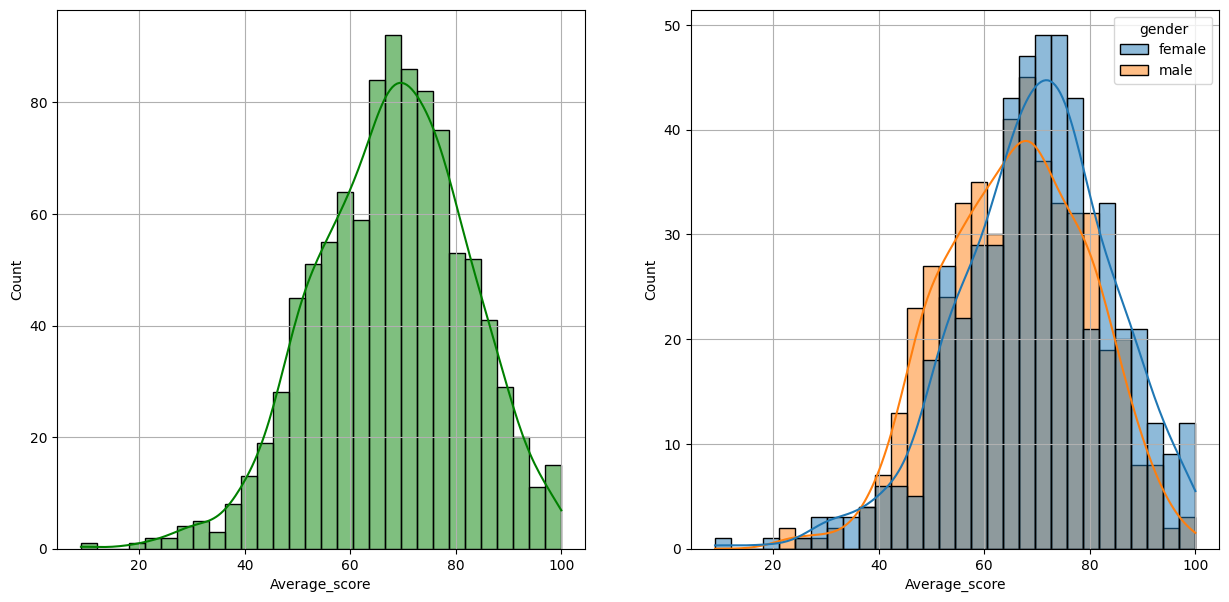

In [66]:
fig, ax= plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='Average_score', kde=True,bins=30, color='g')
plt.grid()
plt.subplot(122)
sns.histplot(data=df, x='Average_score', kde=True, bins=30, hue='gender')
plt.grid()
plt.show()